In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\msi\Desktop\Hendy\Portfolio\Asheville Airbnb\listings.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,NaN,28806,35.578640,-82.595780,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16,NaN
1,197263,Tranquil Room & Private Bath,961396,Timothy,NaN,28806,35.577350,-82.638040,Private room,44.0,2,87,2024-09-08,0.56,2,73,5,NaN
2,209068,Terrace Cottage,1029919,Kevin,NaN,28804,35.617641,-82.551819,Entire home/apt,90.0,30,67,2025-05-03,0.40,1,268,2,NaN
3,246315,Asheville Dreamer's Cabin,1292070,Annie,NaN,28805,35.596150,-82.506350,Private room,61.0,7,53,2019-10-30,0.32,3,62,0,NaN
4,314540,Asheville Urban Farmhouse Entire Home 4.6 mi t...,381660,Tom,NaN,28806,35.585610,-82.627310,Entire home/apt,200.0,1,35,2025-06-13,0.22,1,139,11,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2876 entries, 0 to 2875
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              2876 non-null   int64  
 1   name                            2876 non-null   object 
 2   host_id                         2876 non-null   int64  
 3   host_name                       2876 non-null   object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   2876 non-null   int64  
 6   latitude                        2876 non-null   float64
 7   longitude                       2876 non-null   float64
 8   room_type                       2876 non-null   object 
 9   price                           2536 non-null   float64
 10  minimum_nights                  2876 non-null   int64  
 11  number_of_reviews               2876 non-null   int64  
 12  last_review                     26

In [4]:
# there are 2 columns with all null values
# columns needed attention with null values : price, last_review and reviews_per_month (where both reviews had the same values)
# wrong datatpyes for host_id, and last_review

In [5]:
df.drop(columns=['neighbourhood_group','license'], inplace = True)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2876 entries, 0 to 2875
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              2876 non-null   int64  
 1   name                            2876 non-null   object 
 2   host_id                         2876 non-null   int64  
 3   host_name                       2876 non-null   object 
 4   neighbourhood                   2876 non-null   int64  
 5   latitude                        2876 non-null   float64
 6   longitude                       2876 non-null   float64
 7   room_type                       2876 non-null   object 
 8   price                           2536 non-null   float64
 9   minimum_nights                  2876 non-null   int64  
 10  number_of_reviews               2876 non-null   int64  
 11  last_review                     2613 non-null   object 
 12  reviews_per_month               26

In [8]:
# no duplicates
# changing data types

In [9]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [10]:
df['host_id'] = df['host_id'].astype(str)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2876 entries, 0 to 2875
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              2876 non-null   int64         
 1   name                            2876 non-null   object        
 2   host_id                         2876 non-null   object        
 3   host_name                       2876 non-null   object        
 4   neighbourhood                   2876 non-null   int64         
 5   latitude                        2876 non-null   float64       
 6   longitude                       2876 non-null   float64       
 7   room_type                       2876 non-null   object        
 8   price                           2536 non-null   float64       
 9   minimum_nights                  2876 non-null   int64         
 10  number_of_reviews               2876 non-null   int64         
 11  last

In [12]:
# dealing with null prices

df[df['price'].isna()].head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
6,436476,"8 min Walk to DT AVL! Hip, Chic % Sparkling CLEAN",478398,Heidi,28801,35.60153,-82.56040,Entire home/apt,NaN,2,410,2024-06-26,2.58,3,0,1
37,1728187,Peace and Quiet in town Pets welcome,320564,Lisa,28801,35.60644,-82.55594,Entire home/apt,NaN,3,59,2024-11-09,0.44,1,194,2
39,1851921,"Guest suite - private entrance, hot tub, walkable",1816805,Audrey,28801,35.59467,-82.54444,Entire home/apt,NaN,3,45,2024-02-19,0.43,1,0,0
48,2569529,Downtown Asheville 2 bed/2bath unit for rent,8671251,Heather,28801,35.60110,-82.55586,Entire home/apt,NaN,180,10,2016-07-04,0.07,1,365,0
53,3225871,Little forest 5 mins from airport,16293519,Chun,28732,35.44101,-82.50573,Entire home/apt,NaN,1,89,2019-09-16,0.81,1,0,0


In [13]:
# we can see where the price is null, there is transaction, so it can't be deleted
# we can assume the price to be mean based on price distribution aso to not changed the respective statistical data

In [14]:
df['price'].describe()

count    2536.000000
mean      181.261435
std       222.095805
min        18.000000
25%        90.000000
50%       128.000000
75%       204.000000
max      6846.000000
Name: price, dtype: float64

In [15]:
df1 = df.copy()
df1['price'] = df1['price'].fillna(df1['price'].mean())
df1['price'].describe()

count    2876.000000
mean      181.261435
std       208.550105
min        18.000000
25%        95.000000
50%       142.500000
75%       190.000000
max      6846.000000
Name: price, dtype: float64

In [16]:
# price is done , now move to last_review
# checking the date range

In [17]:
df1[df1['last_review'].isna()].head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
57,3445336,Bungalow in Downtown Asheville,17363326,Michael,28801,35.591830,-82.546260,Entire home/apt,181.261435,30,0,NaT,NaN,2,365,0
72,4809731,Stylish house near downtown,12679902,Summer,28805,35.587338,-82.535442,Entire home/apt,104.000000,30,0,NaT,NaN,1,358,0
285,17346773,Contemporary home five minutes from downtown,84150222,Mary Vivian,28804,35.621800,-82.534430,Entire home/apt,630.000000,2,0,NaT,NaN,4,299,0
294,17638102,True Asheville B&B- Wall Street Room- 2nd Floor,1786031,Emilie,28801,35.604550,-82.550640,Private room,181.261435,20,0,NaT,NaN,3,52,0
602,28843687,West Asheville Haven,6686569,Jaclyn,28806,35.570840,-82.589880,Entire home/apt,181.261435,28,0,NaT,NaN,1,263,0


In [18]:
df1['last_review'].describe()

count                             2613
mean     2024-12-30 14:59:22.801377792
min                2015-10-03 00:00:00
25%                2024-10-11 00:00:00
50%                2025-05-18 00:00:00
75%                2025-06-03 00:00:00
max                2025-06-16 00:00:00
Name: last_review, dtype: object

In [19]:
review = pd.read_csv(r"C:\Users\msi\Desktop\Hendy\Portfolio\Asheville Airbnb\reviews.csv")
review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318549 entries, 0 to 318548
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   listing_id  318549 non-null  int64 
 1   date        318549 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.9+ MB


In [20]:
review.rename(columns={'listing_id': 'id', 'date': 'reviewed_date'}, inplace=True)
review.head()

,id,reviewed_date
0,155305,2011-07-31
1,155305,2011-08-23
2,155305,2011-09-19
3,155305,2011-10-28
4,155305,2012-07-01


In [21]:
review['reviewed_date'] = pd.to_datetime(review['reviewed_date'])
review['reviewed_date'].describe()

count                           318549
mean     2021-11-05 02:13:40.809358080
min                2011-07-31 00:00:00
25%                2020-03-13 00:00:00
50%                2022-04-07 00:00:00
75%                2023-09-30 00:00:00
max                2025-06-16 00:00:00
Name: reviewed_date, dtype: object

In [22]:
df2 = pd.merge(df1,review, on='id', how='left')
df2.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,reviewed_date
0,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,35.57864,-82.59578,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16,2011-07-31
1,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,35.57864,-82.59578,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16,2011-08-23
2,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,35.57864,-82.59578,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16,2011-09-19
3,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,35.57864,-82.59578,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16,2011-10-28
4,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,35.57864,-82.59578,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16,2012-07-01


In [23]:
# we can see we have data ranging from 2015 until 2025, it is too wide to be analyzed, so we only analyze 5 years starting from 2021

In [24]:
df3 = df2[df2['reviewed_date'].between('01-01-2021', df2['reviewed_date'].max())]
df3['reviewed_date'].describe()
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216015 entries, 280 to 318807
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              216015 non-null  int64         
 1   name                            216015 non-null  object        
 2   host_id                         216015 non-null  object        
 3   host_name                       216015 non-null  object        
 4   neighbourhood                   216015 non-null  int64         
 5   latitude                        216015 non-null  float64       
 6   longitude                       216015 non-null  float64       
 7   room_type                       216015 non-null  object        
 8   price                           216015 non-null  float64       
 9   minimum_nights                  216015 non-null  int64         
 10  number_of_reviews               216015 non-null  int64     

In [25]:
# data is already cleaned of null values
# checking for data distribution to examine any outliers

In [26]:
statistic_row = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month",
                     "calculated_host_listings_count", "availability_365", "number_of_reviews_ltm"]

pd.DataFrame({"Skew" : df3[statistic_row].skew(),
              "Kurtosis" : df3[statistic_row].kurt()}
            )

,Skew,Kurtosis
price,5.568856,58.784035
minimum_nights,34.394052,1274.306432
number_of_reviews,1.462246,2.783048
reviews_per_month,1.228173,3.379461
calculated_host_listings_count,4.441509,18.900003
availability_365,-0.568380,-0.971813
number_of_reviews_ltm,1.582466,3.943595


In [27]:
# there are large skew and kurtosis on price and minimum nights, let's dig down into it

In [28]:
df3[statistic_row].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,216015.000000,216015.000000,216015.000000,216015.00000,216015.000000,216015.000000,216015.000000
mean,146.055687,2.864931,283.830456,4.10820,7.040821,225.586482,31.206689
std,111.298382,19.445623,230.145953,2.51267,20.263067,113.255918,26.418384
min,18.000000,1.000000,1.000000,0.02000,1.000000,0.000000,0.000000
25%,87.000000,1.000000,112.000000,2.26000,1.000000,140.000000,12.000000
50%,119.000000,2.000000,224.000000,3.67000,1.000000,253.000000,25.000000
75%,181.261435,2.000000,400.000000,5.49000,3.000000,328.000000,43.000000
max,2043.000000,730.000000,1448.000000,19.96000,108.000000,365.000000,186.000000


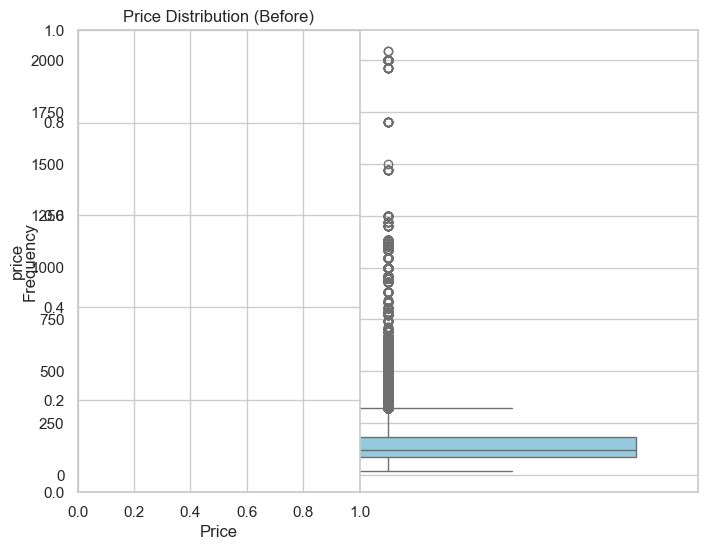

In [29]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.boxplot(df3['price'], color='skyblue')
plt.subplot(1, 2, 1)
plt.title('Price Distribution (Before)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [30]:
df4 = df3.copy().reset_index(drop=True)

In [31]:
# outliers handling
statistic_row = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month",
                     "calculated_host_listings_count", "availability_365", "number_of_reviews_ltm"]

for col in statistic_row:
    q1, q3 = df4[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    df4[col] = df4[col].clip(lower = lower_bound, upper = upper_bound)

In [32]:
df4[statistic_row].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,216015.000000,216015.000000,216015.000000,216015.000000,216015.000000,216015.000000,216015.000000
mean,137.599638,1.676080,278.445876,4.070653,2.327329,225.586482,30.401509
std,69.646663,0.694268,212.206845,2.366664,1.815840,113.255918,23.698938
min,18.000000,1.000000,1.000000,0.020000,1.000000,0.000000,0.000000
25%,87.000000,1.000000,112.000000,2.260000,1.000000,140.000000,12.000000
50%,119.000000,2.000000,224.000000,3.670000,1.000000,253.000000,25.000000
75%,181.261435,2.000000,400.000000,5.490000,3.000000,328.000000,43.000000
max,322.653588,3.500000,832.000000,10.335000,6.000000,365.000000,89.500000


In [33]:
pd.DataFrame({"Skew" : df4[statistic_row].skew(),
              "Kurtosis" : df4[statistic_row].kurt()}
            )

,Skew,Kurtosis
price,1.135753,0.791023
minimum_nights,0.713385,-0.106734
number_of_reviews,0.988215,0.272942
reviews_per_month,0.681940,-0.180997
calculated_host_listings_count,1.145783,-0.213523
availability_365,-0.568380,-0.971813
number_of_reviews_ltm,0.896423,-0.010238


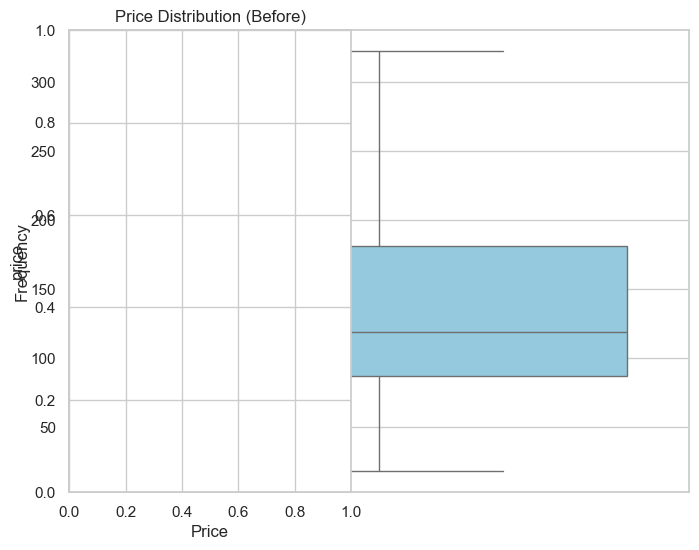

In [34]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.boxplot(df4['price'], color='skyblue')
plt.subplot(1, 2, 1)
plt.title('Price Distribution (Before)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [35]:
# it seems, this data is clipped too much, and it can't be used as too much data looses
# we are making another one with smaller clipping while maintaining usability however has a few outliers inside

In [36]:
df5 = df3.copy().reset_index(drop=True)

for col in statistic_row:
    lower, upper = df5[col].quantile([0.01,0.99])

    df5[col] = df5[col].clip(lower=lower, upper=upper)

In [37]:
df5[statistic_row].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,216015.000000,216015.000000,216015.000000,216015.000000,216015.000000,216015.000000,216015.000000
mean,142.698258,2.272551,282.060158,4.078906,7.040821,225.578710,30.865250
std,86.057107,4.151424,222.704075,2.383533,20.263067,113.246383,24.992965
min,41.000000,1.000000,11.000000,0.370000,1.000000,0.000000,0.000000
25%,87.000000,1.000000,112.000000,2.260000,1.000000,140.000000,12.000000
50%,119.000000,2.000000,224.000000,3.670000,1.000000,253.000000,25.000000
75%,181.261435,2.000000,400.000000,5.490000,3.000000,328.000000,43.000000
max,525.000000,30.000000,1052.000000,10.830000,108.000000,364.000000,110.000000


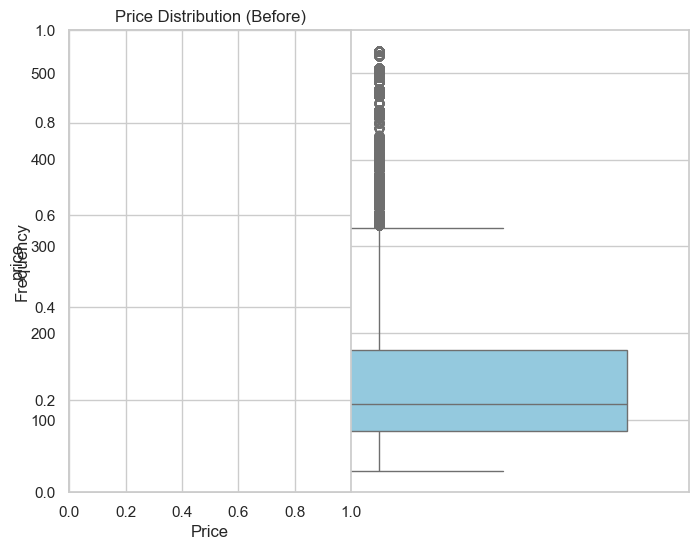

In [38]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.boxplot(df5['price'], color='skyblue')
plt.subplot(1, 2, 1)
plt.title('Price Distribution (Before)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [39]:
pd.DataFrame({"Skew" : df5[statistic_row].skew(),
              "Kurtosis" : df5[statistic_row].kurt()}
            )

,Skew,Kurtosis
price,2.099138,5.455044
minimum_nights,6.195376,37.764270
number_of_reviews,1.213744,1.215888
reviews_per_month,0.726193,-0.043312
calculated_host_listings_count,4.441509,18.900003
availability_365,-0.568627,-0.971793
number_of_reviews_ltm,1.125616,0.869457


In [40]:
# we are using df5 because df4 has too much value got haircut and by all means it loses it's purpose although still contain outliers in a way that is still acceptable

In [41]:
# done with the data cleaning and standardizing, now move to questions or tasks

__You are a Data Analyst at a travel research firm tasked with analyzing Airbnb activity in Asheville, NC. Your goal is to evaluate pricing, demand, and host activity trends to help a travel startup decide whether whether to expand services in Asheville.__
<p>
Your manager says:
</p>

#### “We’re exploring Asheville as a target market. Can you analyze this Airbnb data and tell me:
    1. What pricing trends look like?
    2. Which neighborhoods and hosts are most active?
    3. What review activity says about demand?”


What we can do are :

1. checking price towards neighbourhood in means of price vs neighbourhood, price vs room types, price vs minimum_nights, price vs number_reviews
2. checking how many listings does hosts listed
3. Checking demand through review

In [42]:
# pricing trends based on neighbourhood

df_clean = df5.copy().reset_index(drop=True)

In [43]:
df_calc = df_clean.groupby('host_id')['calculated_host_listings_count'].mean().reset_index()
df_calc['calculated_host_listings_count'].sum()

np.float64(2726.0)

In [44]:
# there are total 2.726 listings in Asheville

In [45]:
df_clean.groupby(["host_id", "host_name"])["id"].nunique().sort_values(ascending = False)[:10]

host_id    host_name                       
167186184  Towns                               105
96187307   Yonder                               48
134903005  Carolina Mornings                    44
121681645  Evolve                               30
480217041  AvantStay                            27
242474849  Jennifer                             26
151279507  Amanda Elizabeth                     18
46001530   Jonathan                             17
250328755  River Row Flats, Inc                 15
581734305  Asheville Cabins Of Willow Winds     12
Name: id, dtype: int64

In [46]:
df_clean['room_type'].value_counts(normalize=True) * 100

room_type
Entire home/apt    91.596880
Private room        7.727241
Shared room         0.570794
Hotel room          0.105085
Name: proportion, dtype: float64

In [47]:
# room that are listed on airbnb mostly an apartment by roughly 91.5% in contract with hotel room by roughly 0.1%

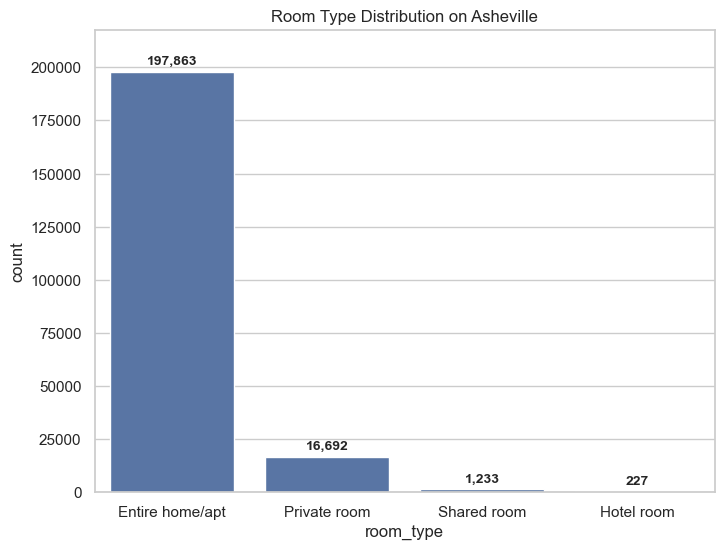

In [48]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x=df_clean['room_type'])
for container in ax.containers:
    labels = [f'{val:,.0f}' for val in container.datavalues]
    ax.bar_label(container,labels=labels, padding=3, fontsize=10, fontweight='bold')
plt.title('Room Type Distribution on Asheville')
plt.ylim(0, df_clean['room_type'].value_counts().max() * 1.1)
plt.savefig("room_type_distribution_on_Asheville.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [49]:
room_type_num = {
    'Entire home/apt':1,
    'Private room':2,
    'Shared room':3,
    'Hotel room':4
}

df_clean['room_level'] = df_clean['room_type'].map(room_type_num).astype(int)

In [50]:
df_clean[['room_level', 'price']].corr()

,room_level,price
room_level,1.000000,-0.180563
price,-0.180563,1.000000


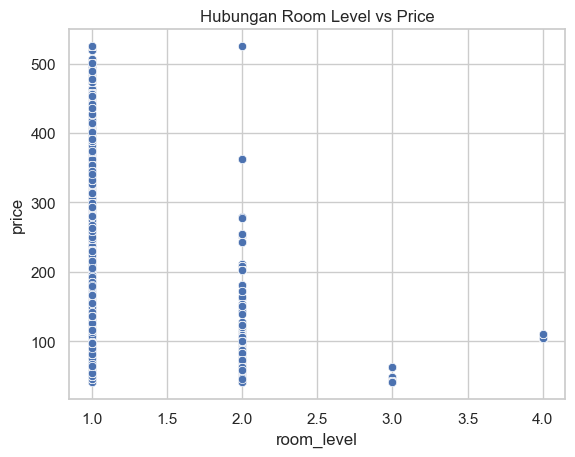

In [51]:
sns.scatterplot(data=df_clean, x='room_level', y='price')
plt.title('Hubungan Room Level vs Price')
plt.show()

In [52]:
# we can see from this chart, customers are favoring towards entire home/apt despite prices
# next we drill down to neighbourhood

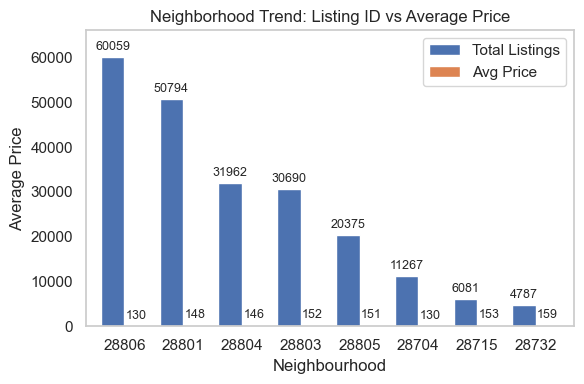

In [53]:
df_nbh_trend = df_clean.groupby('neighbourhood').agg({
    'id':'count',
    'price':'mean'
    }).sort_values(by='id',ascending=False)

ax = df_nbh_trend.plot(kind='bar', figsize=(6, 4), width=0.8)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', fontsize=9)

ax.set_ylim(0, df_nbh_trend['id'].max() * 1.1)
plt.title('Neighborhood Trend: Listing ID vs Average Price')
plt.ylabel('Average Price')
plt.xlabel('Neighbourhood')
plt.xticks(rotation=0)
plt.legend(['Total Listings', 'Avg Price'])
plt.tight_layout()
plt.grid(False)
plt.show()


From the graph, we can see neighbourhood 28806 has the most listings in Ashville AirBnb activities. It forces the host listings to reduce its prices as competitiveness advantage.

In [54]:
df_clean.groupby('neighbourhood')['minimum_nights'].mean().sort_values(ascending=False)


neighbourhood
28803    2.686543
28805    2.427681
28801    2.357503
28806    2.235152
28732    2.235011
28704    2.145114
28804    1.851887
28715    1.799868
Name: minimum_nights, dtype: float64

In [55]:
# neighbourhood 28803 has the most nights to stay in average
# let's see the most expensive one

In [56]:
df_clean.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)[:5]

neighbourhood
28732    158.598497
28715    152.900021
28803    151.771602
28805    151.208954
28801    147.519801
Name: price, dtype: float64

In [57]:
df_clean.groupby('neighbourhood').agg({'price':'mean', 'minimum_nights':'mean'}).sort_values(by='price',ascending=False)[:5]

,price,minimum_nights
neighbourhood,,
28732,158.598497,2.235011
28715,152.900021,1.799868
28803,151.771602,2.686543
28805,151.208954,2.427681
28801,147.519801,2.357503


In [58]:
# turns out neighbourhood 28732 is the most expensive
# let's see the relationship between price and minimum_nights

<Axes: xlabel='minimum_nights'>

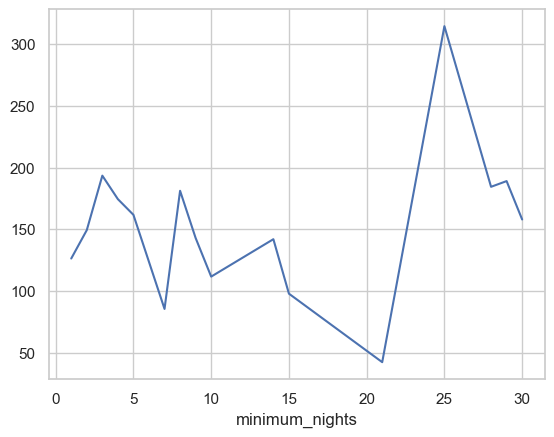

In [59]:
df_clean.groupby('minimum_nights')['price'].mean().plot()

In [60]:
df_clean[["minimum_nights", "price"]].corr()

,minimum_nights,price
minimum_nights,1.000000,0.067941
price,0.067941,1.000000


It shows the correlation between minimun_nights and price are so little and so diminishing as the data shows trends in people staying in entire home/apt. It means that people were booking for a family trips (considering many people are staying in an listing provided)

In [61]:
df_clean['neighbourhood'].unique()

array([28806, 28804, 28803, 28801, 28805, 28704, 28732, 28715])

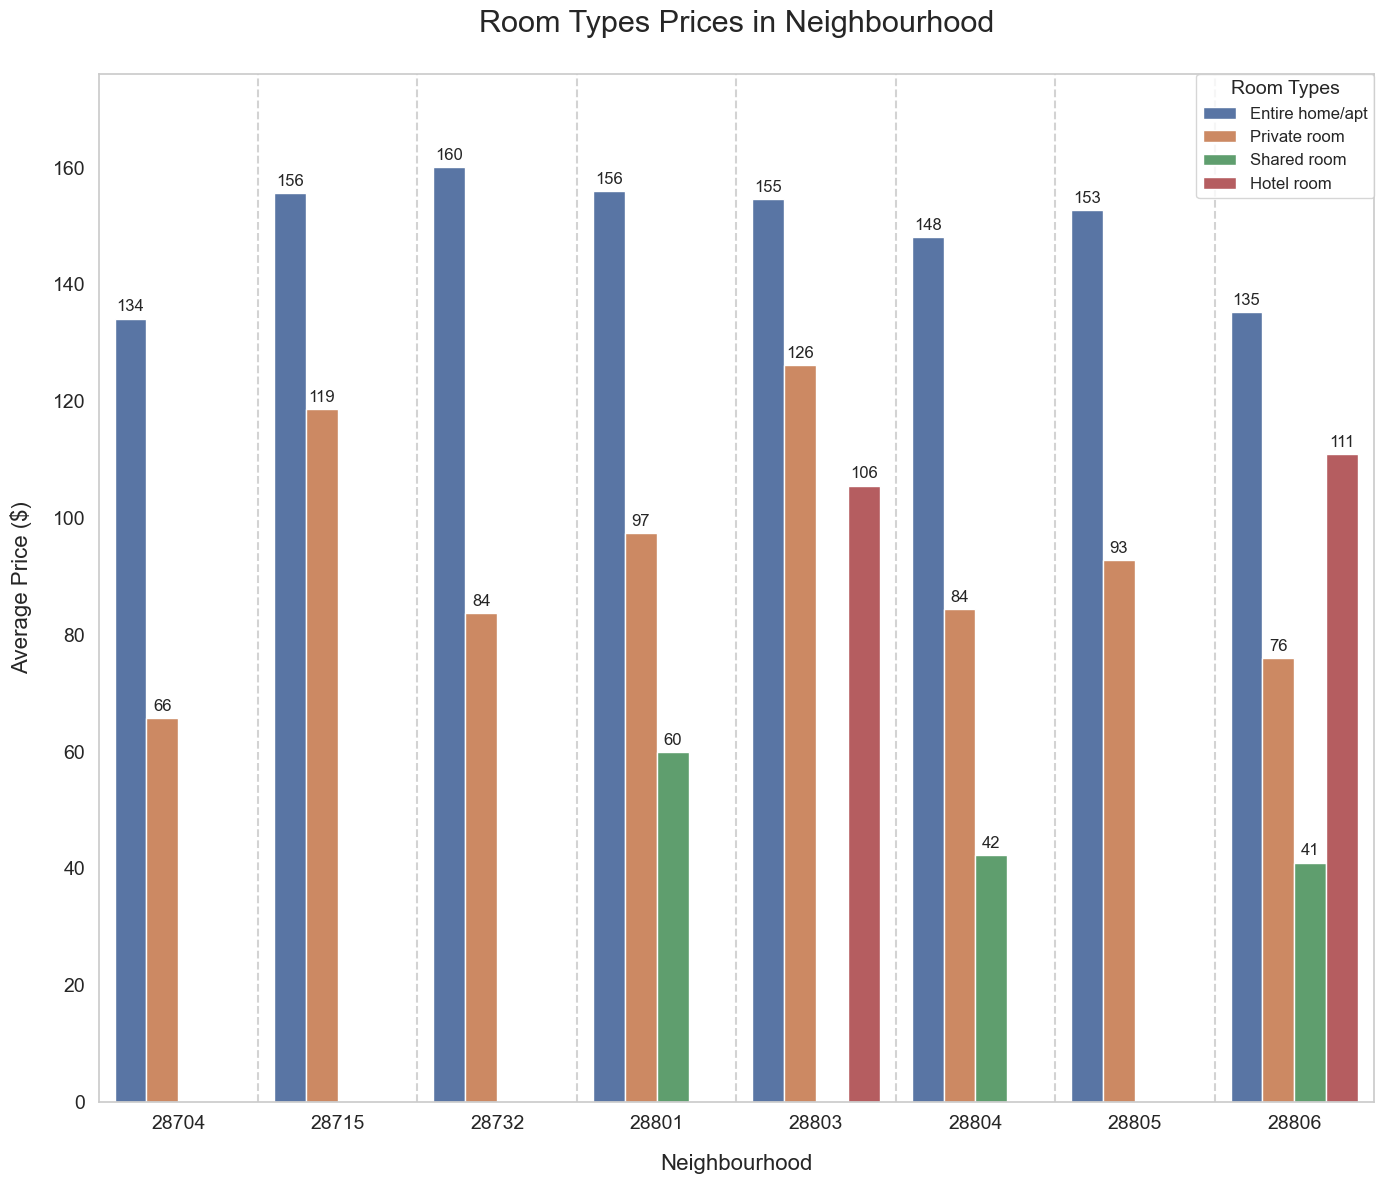

In [62]:
df_nbh_rt_price = df_clean.groupby(['neighbourhood','room_type'])['price'].mean().reset_index()
plt.figure(figsize=(14,12))
ax = sns.barplot(data=df_nbh_rt_price, x='neighbourhood', y='price', hue='room_type', width=0.8)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', fontsize=12)
    
for i in range(len(df_nbh_rt_price['neighbourhood'].unique()) - 1):
    plt.axvline(i + 0.5, color='lightgrey', linestyle='--', linewidth=1.5)

plt.xlabel('Neighbourhood', fontsize=16, labelpad=15)
plt.ylabel('Average Price ($)', fontsize=16, labelpad=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Room Types Prices in Neighbourhood', fontsize=22, pad=30)
plt.legend(title='Room Types', title_fontsize=14, fontsize=12, loc='upper right', borderaxespad=0)
ax.set_ylim(0, df_nbh_rt_price['price'].max() * 1.1)
plt.xticks(rotation=0)

plt.grid(False)
plt.tight_layout()
plt.show()

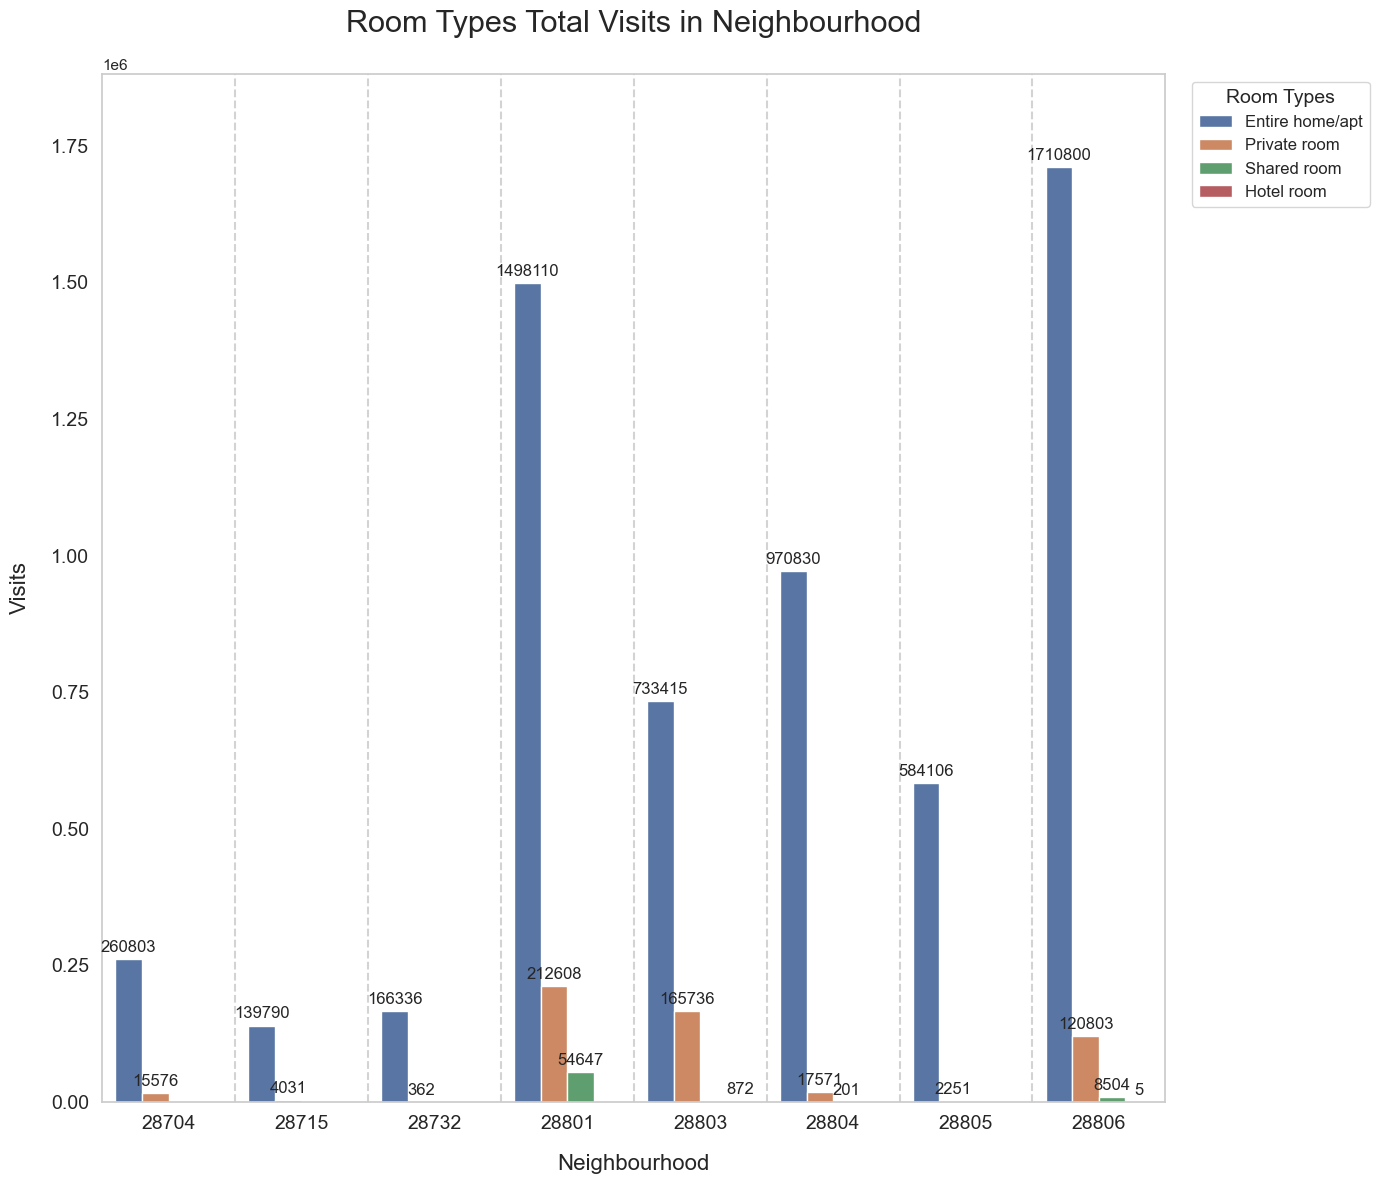

In [63]:
df_nbh_rt_review = df_clean.groupby(['neighbourhood','room_type'])['number_of_reviews_ltm'].sum().reset_index()
plt.figure(figsize=(14,12))
ax = sns.barplot(data=df_nbh_rt_review, x='neighbourhood', y='number_of_reviews_ltm', hue='room_type', width=0.8)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', fontsize=12)
    
for i in range(len(df_nbh_rt_review['neighbourhood'].unique()) - 1):
    plt.axvline(i + 0.5, color='lightgrey', linestyle='--', linewidth=1.5)

plt.xlabel('Neighbourhood', fontsize=16, labelpad=15)
plt.ylabel('Visits', fontsize=16, labelpad=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Room Types Total Visits in Neighbourhood', fontsize=22, pad=30)
plt.legend(title='Room Types', title_fontsize=14, fontsize=12, bbox_to_anchor=(1.2,1), loc='upper right')
ax.set_ylim(0, df_nbh_rt_review['number_of_reviews_ltm'].max() * 1.1)
plt.xticks(rotation=0)

plt.grid(False)
plt.tight_layout()
plt.show()

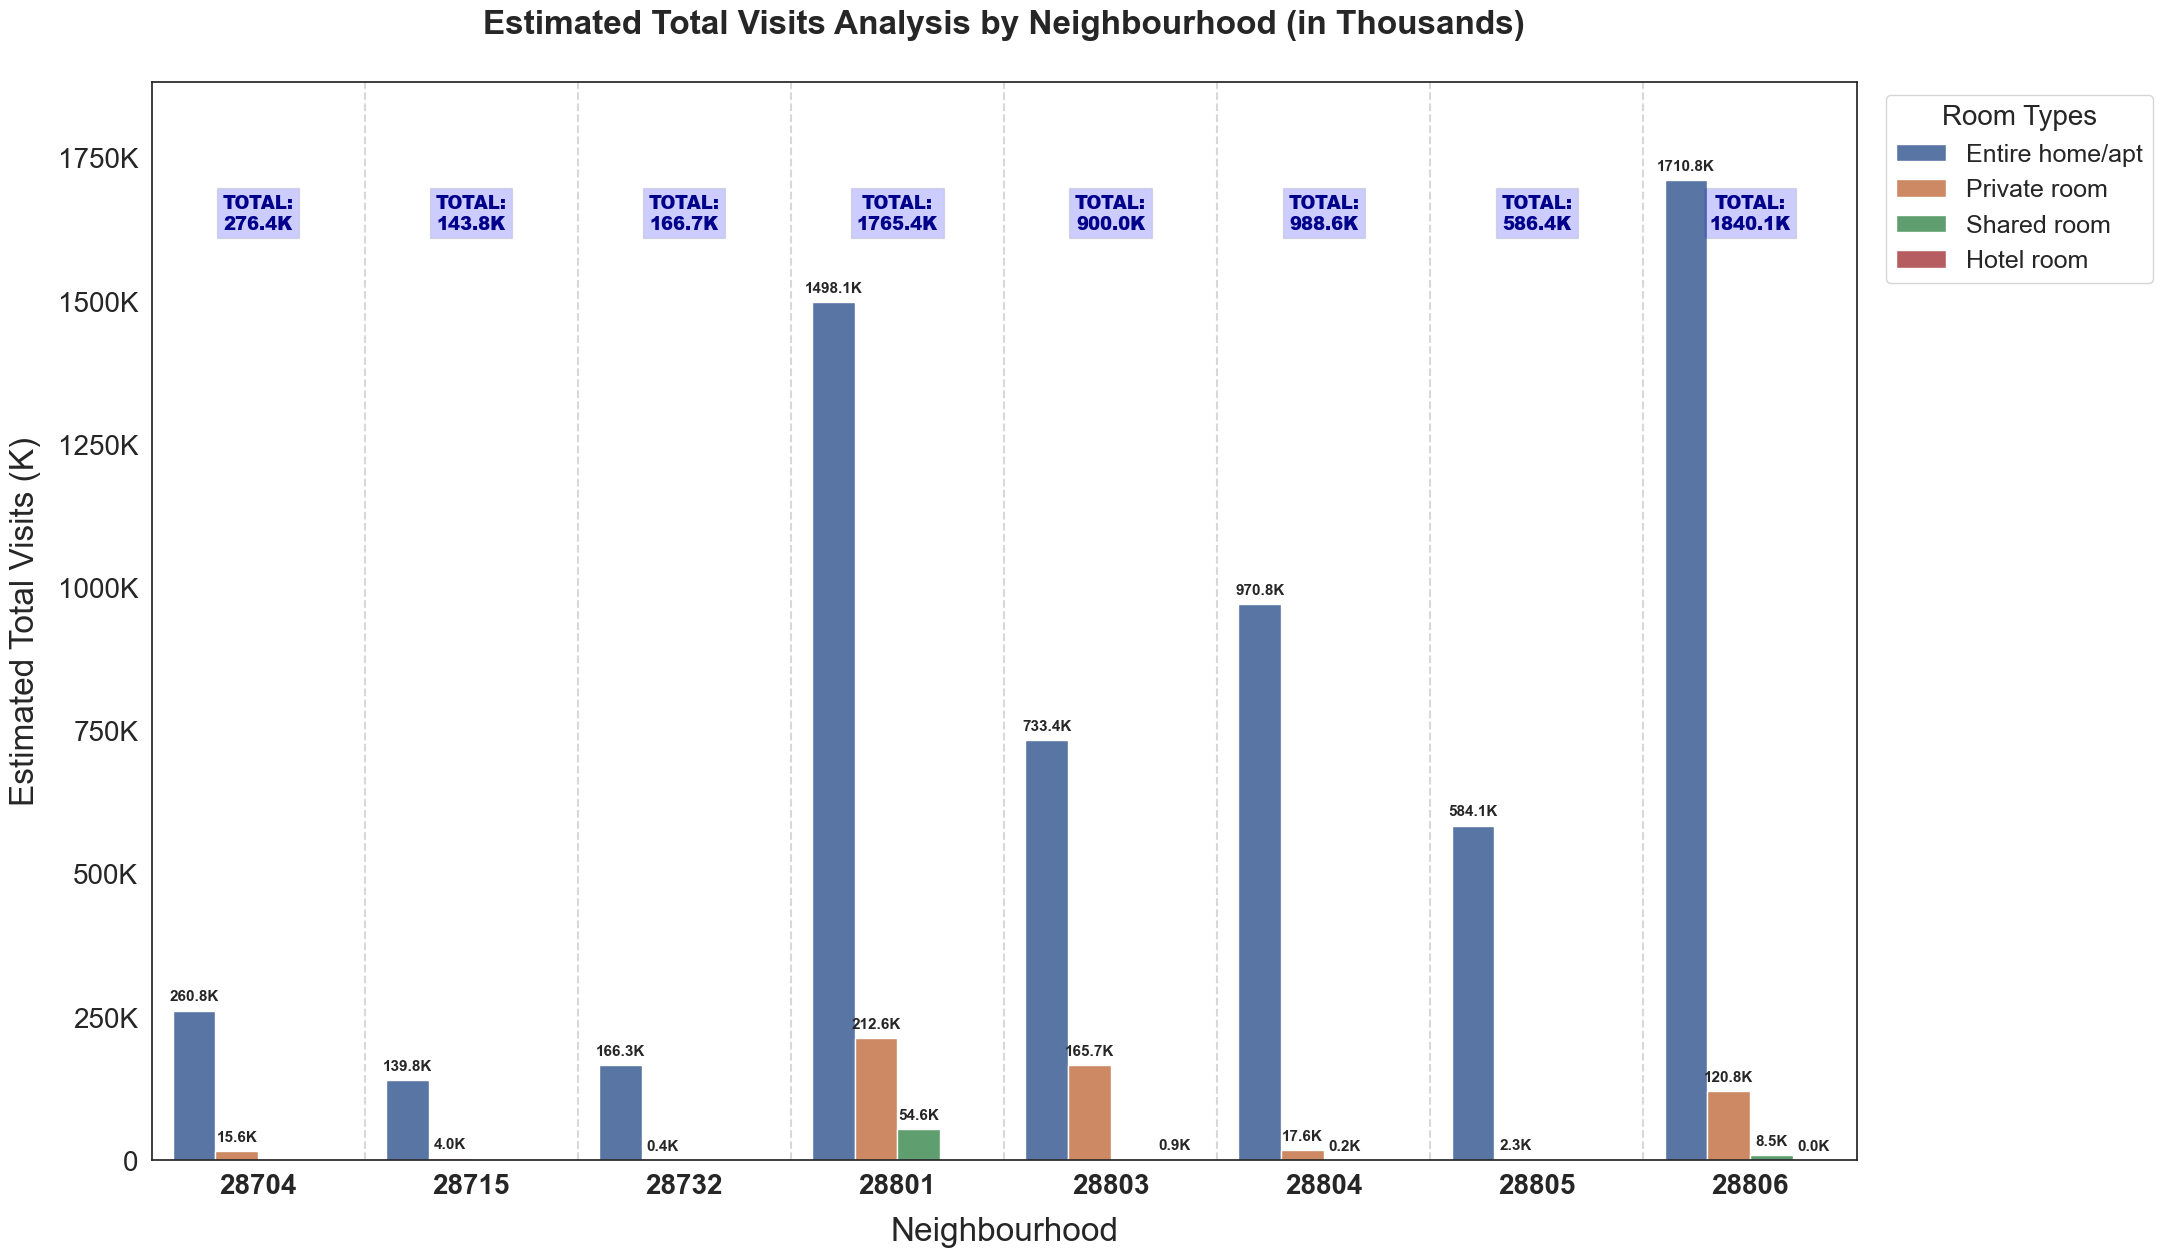

In [64]:
import matplotlib.ticker as ticker

# 1. Menyiapkan Data
# Data detail per Room Type
df_visits = df_clean.groupby(['neighbourhood', 'room_type'])['number_of_reviews_ltm'].sum().reset_index()
# Data total per Zipcode (untuk bagian atas kotak)
df_total_zip = df_clean.groupby('neighbourhood')['number_of_reviews_ltm'].sum()

# Fungsi pembantu untuk mengubah angka ke format "K" (Contoh: 260803 -> 261K)
def format_k(x, pos):
    return f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'

# 2. Setup Plot
plt.figure(figsize=(22, 14))
sns.set_style("white")

# 3. Membuat Bar Plot
# dodge=True memastikan batang dikelompokkan menyamping
ax = sns.barplot(data=df_visits, x='neighbourhood', y='number_of_reviews_ltm', hue='room_type', width=0.8)

# 4. Menambahkan Label "K" di Atas Setiap Batang
for container in ax.containers:
    labels = [f'{val/1000:.1f}K' if val > 0 else '' for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontsize=11, fontweight='bold')

# 5. Menambahkan Ringkasan TOTAL di Bagian Atas Setiap Kotak Zipcode
for i, (zipcode, total_val) in enumerate(df_total_zip.items()):
    ax.text(i, ax.get_ylim()[1] * 0.92, f'TOTAL:\n{total_val/1000:.1f}K', 
            ha='center', va='center', fontsize=13, color='darkblue',
            fontweight='black', bbox=dict(facecolor='blue', alpha=0.2, edgecolor='grey'))

# 6. Membuat Sekat Vertikal (Grid per Zipcode)
for i in range(len(df_total_zip) - 1):
    plt.axvline(i + 0.5, color='grey', linestyle='--', alpha=0.3)

# 7. Mengatur Format Sumbu Y menjadi "K"
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_k))

# 8. Memperbesar Label dan Judul
plt.title('Estimated Total Visits Analysis by Neighbourhood (in Thousands)', fontsize=24, pad=35, fontweight='bold')
plt.xlabel('Neighbourhood', fontsize=24, labelpad=12)
plt.ylabel('Estimated Total Visits (K)', fontsize=24, labelpad=12)
plt.xticks(fontsize=20, fontweight='bold')
plt.yticks(fontsize=20)

# 9. Merapikan Legenda
plt.legend(title='Room Types', title_fontsize=20, fontsize=18, bbox_to_anchor=(1.01, 1), loc='upper left')

# Memberi ruang ekstra di atas agar label "TOTAL" tidak terpotong
ax.set_ylim(0, df_visits['number_of_reviews_ltm'].max() * 1.1)

# sns.despine() # Menghilangkan garis bingkai atas & kanan agar bersih
# plt.tight_layout()
plt.show()


As we can see, in neighbourhood of 28806 offered complete range of room types avaialable to customers in Ashville thus making it the most 

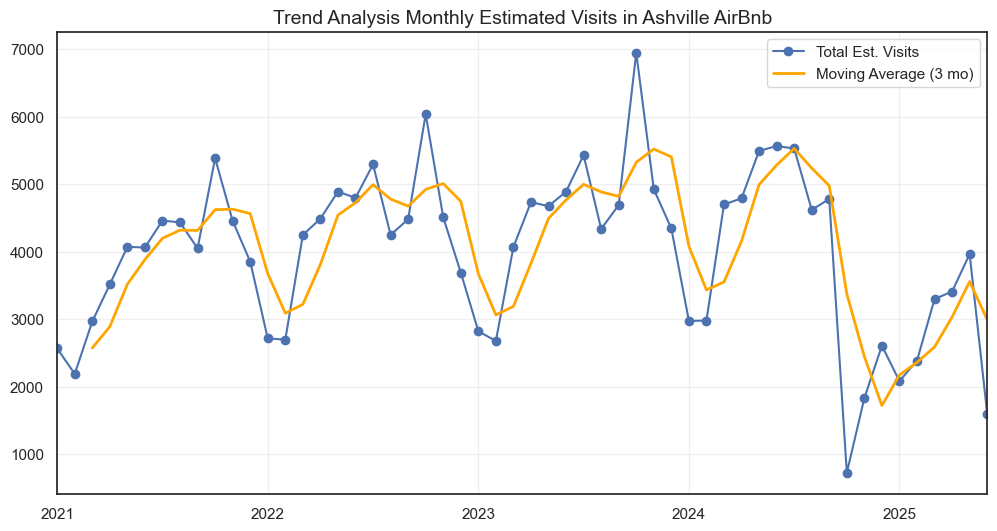

In [65]:
df_temp = df_clean.set_index('reviewed_date')

monthly_data = df_temp.resample('MS').size()

plt.figure(figsize=(12, 6))
monthly_data.plot(kind='line', marker='o', label='Total Est. Visits')

monthly_data.rolling(window=3).mean().plot(color='orange', label='Moving Average (3 mo)', linewidth=2)

plt.title('Trend Analysis Monthly Estimated Visits in Ashville AirBnb', fontsize=14)
plt.xlabel('')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [66]:
df_temp.resample('YS').size().pct_change()

reviewed_date
2021-01-01         NaN
2022-01-01    0.132190
2023-01-01    0.046833
2024-01-01   -0.145545
2025-01-01   -0.640445
Freq: YS-JAN, dtype: float64

In [67]:
# it shows positive growth from 2022 towards 2023, after that it keeps on declining.
# we can see it clearly from the peak of moving average from 2024 to 2025 is moving downwards.
# supported by the through of moving average from 2024 to 2025 also moving downwards.

In [68]:
df_pct_host = df_clean.groupby('host_id').agg({
            'calculated_host_listings_count':'mean',
            'reviewed_date':'count',
            'price':'mean'}).reset_index()

# df_total = df_pct.sum()
df_pct_host['pct_reviewed'] = round(df_pct_host['reviewed_date']/len(df_clean)*100,4)
df_pct_host['pct_listings'] = round(df_pct_host['calculated_host_listings_count']/len(df_clean)*100,4)                             

df_pct_host.sort_values(by=['pct_reviewed','pct_listings'], ascending=[False, False]).head(10)
    # .sort_values(by='pct_bookings',ascending=False)

,host_id,calculated_host_listings_count,reviewed_date,price,pct_reviewed,pct_listings
328,167186184,108.0,7612,214.056947,3.5238,0.0500
577,242474849,28.0,2527,204.905639,1.1698,0.0130
1112,46001530,17.0,2261,78.628041,1.0467,0.0079
548,23092470,4.0,1734,118.484429,0.8027,0.0019
386,180564557,6.0,1619,116.371834,0.7495,0.0028
39,10699816,7.0,1446,211.383889,0.6694,0.0032
312,16296123,3.0,1304,110.279847,0.6037,0.0014
609,250328755,15.0,1215,135.584249,0.5625,0.0069
881,367363875,8.0,1199,230.134279,0.5551,0.0037
594,246993350,6.0,1191,105.528967,0.5514,0.0028


In [70]:
df_clean.groupby('neighbourhood')['reviews_per_month'].mean().sort_values(ascending=False)

neighbourhood
28801    4.348229
28732    4.250483
28804    4.154589
28803    4.111341
28806    4.098767
28805    3.772126
28715    3.497051
28704    3.251746
Name: reviews_per_month, dtype: float64

# Reports:
AirBnB in Asheville, NC, has total of 2.726 with total 1.653 hosts. It offers 4 types of room types: Entire home/apt, private room, shared room, and hotel room. Host ID 167186184 has the most listings with 105 listings in Asheville, meanwhile neighbourhood 28806 has the most active listings as it invites roughly 1.840 bookings from 2021 until 2025.

## Questions:
1. What pricing trends look like?
2. Which neighbourhoods and hosts are most active?
3. What review activity says about demand?

### Answers:
The most active neighbourhoods was 28806 in which has 60.059 listings with an average price of roughly costs \\$130/ night in which it is similiar with neighbourhood in 28704. The price in 28806 was so competitive due to so many listings in that neighbourhood forcing hosts to reduce its price to gain competitiveness.
<br>
The most active host was 167186184 with a total listings of 108 (0.05 \% of total listings) and 7.612 reviews (3.5 \% of total reviews). The host had the average price of \\$214/ night.
</br>
<br>
The reviews in Asheville had a good rating of 3 or 4 out of 5. It showed a good hospitality and rooms, and projecting it is a good place to visit.
</br>
<br>
The demand in Asheville was growing from the year 2021 through 2023 after COVID in which the peak months of visits are on September and October that. The most concerning facts were in the next year, growth seems declining, <b>as per 2024, it's growth was roughly -14.5%</b>, following the next year of 2025 <b>until June 2025, it showed negative growth as well, roughly -64%</b>. Although it is just half the year, but it was quite impossible to catch up to at least 0% in just 6 months left, hence, the highest visits occured in September and October. <b>This does not show any good sign for expanding the business in Asheville as the business is slowing down.</b>
</br>

## Conclusions:
<b>Asheville is a very good spot with a lot of hosts and listings but with it's growth has been declining, it would be best to postpone/abandon the ideas of startup travel on having expansion in Asheville.</b>